In [50]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


In [51]:
# print(torch.cuda.is_available())
torch.manual_seed(42)
np.random.seed(42)

In [52]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
device

device(type='cuda')

In [53]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.80

In [54]:
# Interior points

N_f = 10000
x_f = np.random.uniform(0, L, N_f)
y_f = np.random.uniform(0, H, N_f)
t_f = np.random.uniform(0, T, N_f)

X_f = np.column_stack([x_f, y_f, t_f])
X_f = torch.tensor(
    X_f,
    dtype=torch.float32,
    device=device,
    requires_grad=True
)

print(X_f.shape)


torch.Size([10000, 3])


In [55]:
# Generate wall points 

# Bottom boundary (x in [0, L], y=0, t in [0, T])
N_wall = 1000
x_bottom = np.linspace(0, L, N_wall)
bottom_pts = np.column_stack([
    x_bottom,
    np.zeros(N_wall),
    np.linspace(0, T, N_wall)
])

# Left boundary (x=0, y in [0, H], t in [0, T])
y_left = np.linspace(0, H, N_wall)
left_pts = np.column_stack([
    np.zeros(N_wall),
    y_left,
    np.linspace(0, T, N_wall)
])

# Right side wall (0->0.30, 0.70->1)
y_right_bottom_side = np.linspace(0, opening_y_min, N_wall // 2)
y_right_top_side = np.linspace(opening_y_max, H, N_wall // 2)

# (x=L, y=0->0.30, t in [0, T])
right_bottom_pts = np.column_stack([
    np.full(len(y_right_bottom_side), L),
    y_right_bottom_side,
    np.linspace(0, T, len(y_right_bottom_side))
])

# (x=L, y=0.70->1, t in [0, T])
right_top_pts = np.column_stack([
    np.full(len(y_right_top_side), L),
    y_right_top_side,
    np.linspace(0, T, len(y_right_top_side))
])


In [56]:
# Combining all wall points 
X_wall = np.vstack([left_pts, bottom_pts, right_bottom_pts, right_top_pts])
X_wall = torch.tensor(X_wall, dtype=torch.float32, device=device)
print(X_wall.shape)

torch.Size([3000, 3])


In [57]:
# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    t_open
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open.shape

torch.Size([500, 3])

In [58]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

In [59]:
import torch
import torch.nn as nn

# 1. Define the primary device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize the model
model = PINN()

# 3. Wrap the model to use all available GPUs
if torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

# 4. Move to the primary device (DataParallel handles the distribution)
model = model.to(device)

# Test forward pass
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)
pred = model(test_pnts)
print(pred)

Let's use 2 GPUs!
tensor([[ 0.0288,  0.0239, -0.0375]], device='cuda:0',
       grad_fn=<GatherBackward>)


In [60]:
print(pred[0,0].item())

0.02877393551170826


In [61]:
def derivatives(output, inputs):
    grad = torch.autograd.grad(
        output,
        inputs,
        grad_outputs=torch.ones_like(output),
        create_graph=True,
        retain_graph=True
    )[0]
    
    return grad

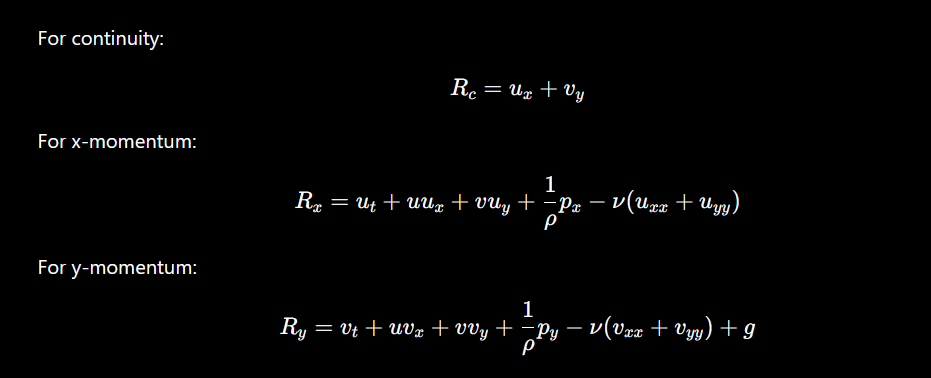

In [62]:
# continuity loss calculation
def continuity_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]
    
    u_x = derivatives(u, x)
    v_y = derivatives(v, y)
    
    R_cont = u_x + v_y
    
    return R_cont

In [63]:
# x-momentum loss
def x_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]
    
    u_x = derivatives(u, x)
    u_y = derivatives(u, y)
    
    u_xx = derivatives(u_x, x)
    u_yy = derivatives(u_y, y)
    
    p_x = derivatives(p, x)

    u_t = derivatives(u, t)
    
    R_x = u_t + u*u_x + v*u_y + ((1/rho)*p_x) - nu*(u_xx + u_yy)
    
    return R_x

In [64]:
# y-momentum loss
# the network now predicts DYNAMIC pressure only.
# True pressure p = p_dynamic + p_hydrostatic, where p_hydrostatic = -rho*g*y
def y_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p_dynamic = pred[:, 2:3]
    
    v_x = derivatives(v, x)
    v_y = derivatives(v, y)
    
    v_xx = derivatives(v_x, x)
    v_yy = derivatives(v_y, y)

    v_t = derivatives(v, t)
    
    p_y = derivatives(p_dynamic, y)
    
    R_y = v_t + u*v_x + v*v_y + (1/rho)*p_y - nu*(v_xx + v_yy)

    return R_y


In [65]:
print(X_f[:, 0], X_f[:, 1], X_f[:, 2])

tensor([0.7491, 1.9014, 1.4640,  ..., 1.8934, 0.7950, 0.4343], device='cuda:0',
       grad_fn=<SelectBackward0>) tensor([0.3736, 0.3329, 0.1762,  ..., 0.3037, 0.4433, 0.1723], device='cuda:0',
       grad_fn=<SelectBackward0>) tensor([0.7300, 0.1845, 0.3466,  ..., 0.0195, 0.4010, 0.2574], device='cuda:0',
       grad_fn=<SelectBackward0>)


In [66]:
R_cont  = continuity_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_x     = x_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_y     = y_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])

print("Continuity residual:",
      R_cont.abs().mean().item())

print("X momentum residual:",
      R_x.abs().mean().item())

print("Y momentum residual:",
      R_y.abs().mean().item())

Continuity residual: 0.023813577368855476
X momentum residual: 0.01802227646112442
Y momentum residual: 0.004171909764409065


In [67]:
def physics_loss():
    x = X_f[:, 0]
    y = X_f[:, 1]
    t = X_f[:, 2]

    R_cont = continuity_loss(model, x, y, t)
    R_x = x_momentum_loss(model, x, y, t)
    R_y = y_momentum_loss(model, x, y, t)

    loss_cont = torch.mean(R_cont**2)
    loss_x = torch.mean(R_x**2)
    loss_y = torch.mean(R_y**2)

    return loss_cont + loss_x + loss_y

In [68]:
# Wall boundary loss (u=0, v=0)
def wall_loss():

    prediction = model(X_wall)

    u_wall = prediction[:, 0]
    v_wall = prediction[:, 1]

    loss_u = torch.mean(u_wall**2)
    loss_v = torch.mean(v_wall**2)

    return loss_u + loss_v

In [69]:
# Opening boundary condition (p=0)
def opening_loss():
    
    prediction = model(X_open)
    p_open = prediction[:, 2]

    return torch.mean(p_open**2)

In [70]:
X_pressure_ref = torch.tensor(
    [[0.0, H, 0.0]],
    dtype=torch.float32,
    device=device
)

def pressure_reference_loss():

    prediction = model(X_pressure_ref)
    p_ref = prediction[:, 2]

    return torch.mean(p_ref**2)

In [71]:
# Initial condition points (t = 0, u = v = 0 everywhere in the domain)
N_ic = 2000
x_ic = np.random.uniform(0, L, N_ic)
y_ic = np.random.uniform(0, H, N_ic)
t_ic = np.zeros(N_ic)

X_ic = np.column_stack([x_ic, y_ic, t_ic])
X_ic = torch.tensor(X_ic, dtype=torch.float32, device=device)
print(X_ic.shape)

def ic_loss():
    pred = model(X_ic)
    u_ic = pred[:, 0]
    v_ic = pred[:, 1]
    return torch.mean(u_ic**2) + torch.mean(v_ic**2)


torch.Size([2000, 3])


In [72]:
# Total loss
# Loss weights - tune these; wall/opening usually need to be weighted up
# relative to physics because rho=1000 makes physics-loss gradients dominate
lambda_phys = 1.0
lambda_wall = 10.0
lambda_open = 10.0
lambda_ref  = 1.0
lambda_ic   = 10.0

def total_loss():

    L_phys = physics_loss()
    L_wall = wall_loss()
    L_open = opening_loss()
    L_ref  = pressure_reference_loss()
    L_ic   = ic_loss()

    loss = (
        lambda_phys * L_phys +
        lambda_wall * L_wall +
        lambda_open * L_open +
        lambda_ref  * L_ref  +
        lambda_ic   * L_ic
    )

    return loss, L_phys, L_wall, L_open, L_ref, L_ic


In [73]:


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=200
)


In [ ]:
import numpy as np

epochs = 1000
resample_every = 200   # refresh collocation points periodically
loss_history = []
loss_components_history = []

def resample_collocation_points():
    global X_f
    x_f = np.random.uniform(0, L, N_f)
    y_f = np.random.uniform(0, H, N_f)
    t_f = np.random.uniform(0, T, N_f)
    X_new = np.column_stack([x_f, y_f, t_f])
    X_f = torch.tensor(X_new, dtype=torch.float32, device=device, requires_grad=True)

# --- Phase 1: Adam ---
for epoch in range(epochs):

    if epoch % resample_every == 0 and epoch > 0:
        resample_collocation_points()

    optimizer.zero_grad()
    (loss, L_phys, L_wall, L_open, L_ref, L_ic) = total_loss()
    loss.backward()
    optimizer.step()
    scheduler.step(loss)

    loss_history.append(loss.item())
    loss_components_history.append(
        (L_phys.item(), L_wall.item(), L_open.item(), L_ref.item(), L_ic.item())
    )

    if epoch % 5 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch+1:5d} | "
            f"Total: {loss.item():.6f} | "
            f"Physics: {L_phys.item():.6f} | "
            f"Wall: {L_wall.item():.6f} | "
            f"Open: {L_open.item():.6f} | "
            f"IC: {L_ic.item():.6f} | "
        )

# Save checkpoint 
checkpoint_path = "pinn_model03_03_08_up.pt"

# Extract the base model state dict (handles both Single-GPU and Multi-GPU setups)
model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

checkpoint = {
    "epoch": epochs,
    "model_state_dict": model_state,
    "optimizer_state_dict": optimizer.state_dict(),
    "loss_history": loss_history,
    "loss_components_history": loss_components_history,
}
torch.save(checkpoint, checkpoint_path)
print(f"Training complete. Checkpoint saved to {checkpoint_path}")

Epoch     1 | Total: 0.215132 | Physics: 0.000955 | Wall: 0.004319 | Open: 0.013768 | IC: 0.003328 | 
Epoch     6 | Total: 0.011616 | Physics: 0.000386 | Wall: 0.000344 | Open: 0.000558 | IC: 0.000159 | 
Epoch    11 | Total: 0.022142 | Physics: 0.000099 | Wall: 0.000126 | Open: 0.001787 | IC: 0.000251 | 
Epoch    16 | Total: 0.012894 | Physics: 0.000279 | Wall: 0.000208 | Open: 0.000901 | IC: 0.000137 | 
Epoch    21 | Total: 0.000569 | Physics: 0.000068 | Wall: 0.000029 | Open: 0.000005 | IC: 0.000016 | 
Epoch    26 | Total: 0.005286 | Physics: 0.000110 | Wall: 0.000102 | Open: 0.000349 | IC: 0.000050 | 
Epoch    31 | Total: 0.001197 | Physics: 0.000057 | Wall: 0.000028 | Open: 0.000061 | IC: 0.000025 | 
Epoch    36 | Total: 0.000923 | Physics: 0.000057 | Wall: 0.000015 | Open: 0.000059 | IC: 0.000012 | 
Epoch    41 | Total: 0.001181 | Physics: 0.000041 | Wall: 0.000019 | Open: 0.000082 | IC: 0.000012 | 
Epoch    46 | Total: 0.000173 | Physics: 0.000040 | Wall: 0.000007 | Open: 0.00000

In [ ]:
import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = r"/kaggle/working/pinn_model03_03_08_up.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]
loss_components_history = checkpoint.get("loss_components_history", [])

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))

plt.semilogy(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("PINN Training Convergence")

plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import torch


def calculate_flow_rate(
    model,
    device,
    time_value,
    x_position=1.0,
    n_points=500
):
    y_values = np.linspace(0.0, 1.0, n_points)
    x_values = np.full_like(y_values, x_position)
    t_values = np.full_like(y_values, time_value)

    input_points = np.column_stack([
        x_values,
        y_values,
        t_values
    ])

    input_tensor = torch.tensor(
        input_points,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        prediction = model(input_tensor)

    # x-direction velocity
    u_values = prediction[:, 0].cpu().numpy()

    # Flow rate magnitude: | integral(u dy) |
    Q_magnitude = abs(np.trapezoid(u_values, y_values))

    return Q_magnitude


time_values = [0.0, 0.25, 0.5, 0.75, 0.1]

q_values = {}

for time_value in time_values:
    Q_magnitude = calculate_flow_rate(
        model=model,
        device=device,
        time_value=time_value,
        x_position=1.0,
        n_points=500
    )

    q_values[time_value] = Q_magnitude

    print(
        f"t = {time_value:.2f}, "
        f"|Q| = {Q_magnitude:.6f} m²/s"
    )

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)

x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)

grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)

u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)

# Velocity magnitude: |V| = sqrt(u^2 + v^2)
velocity_magnitude = np.hypot(u_open, v_open)

# Global parameters updated for a dark theme
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Pure black backgrounds to make lines pop
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#000000")

stream = ax.streamplot(
    X,
    Y,
    u_open,
    v_open,
    color=velocity_magnitude,
    cmap="turbo", # 'turbo' acts as a brilliant neon on pure black
    norm=Normalize(
        vmin=velocity_magnitude.min(),
        vmax=velocity_magnitude.max()
    ),
    density=1.8,
    linewidth=2.6,
    arrowsize=1.5,
    minlength=0.12
)

# Subtle border to frame the plot without distracting from the data
for spine in ax.spines.values():
    spine.set_color("#333333")
    spine.set_linewidth(1.5)

cbar = fig.colorbar(
    stream.lines,
    ax=ax,
    pad=0.025,
    fraction=0.045
)

cbar.set_label(
    "Velocity magnitude",
    fontsize=12,
    fontweight="bold",
    color="white"
)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor('#333333')

ax.set_xlabel("x", fontsize=13, fontweight="bold", color="white")
ax.set_ylabel("y", fontsize=13, fontweight="bold", color="white")

ax.set_title(
    f"PINN Fluid Flow  |  t = {t_plot} | w/o eddy | 0.3 - 0.7 ",
    fontsize=17,
    fontweight="bold",
    color="white",
    pad=16
)


# List of y-coordinates you want to plot
y_lines = [0.3, 0.7]

for y_val in y_lines:
    ax.axhline(
        y=y_val,
        color="red",
        linewidth=3,
        linestyle="-",
        label=f"y = {y_val}",
        zorder=10
    )

# Optional: To avoid duplicate legend labels if you have many lines,
# you can call ax.legend() after this to display the labels.

ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
components = np.array(loss_components_history)
labels = ["Physics", "Wall", "Opening", "Pressure Ref", "IC"]

plt.figure(figsize=(8, 5))
for i, label in enumerate(labels):
    plt.semilogy(components[:, i], label=label)
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Individual Loss Components")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.70

In [ ]:
Nx = 100
Ny = 100
L=2
H=1
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_dynamic_pred = prediction[:, 2].cpu().numpy()

u_pred = u_pred.reshape(Ny, Nx)
v_pred = v_pred.reshape(Ny, Nx)
p_dynamic_pred = p_dynamic_pred.reshape(Ny, Nx)

# Reconstruct TRUE pressure: p = p_dynamic + p_hydrostatic, p_hydrostatic = -rho*g*y
p_hydrostatic = -rho * g * Y
p_pred = p_dynamic_pred + p_hydrostatic


In [ ]:
# import numpy as np

# # Define coordinate arrays
# x = np.array([1, 2, 3])
# y = np.array([4, 5])

# # Generate coordinate matrices
# X, Y = np.meshgrid(x, y)

# print("X Matrix:\n", X)
# print("\nY Matrix:\n", Y)


In [ ]:
velocity_mag = np.sqrt(
    u_pred**2 + v_pred**2
)

plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    velocity_mag,
    levels=50
)

plt.colorbar(
    label="Velocity magnitude"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Velocity Magnitude")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.streamplot(
    X,
    Y,
    u_pred,
    v_pred,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Fluid Flow")

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    p_pred,
    levels=50
)

plt.colorbar(
    label="Pressure"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Pressure Field")

plt.show()

In [ ]:
# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
# t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    np.full(len(y_open), T),
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open.shape

In [ ]:
with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_dynamic_open = opening_prediction[:, 2].cpu().numpy()

# Reconstruct TRUE pressure at the opening (adds back hydrostatic term)
p_hydrostatic_open = -rho * g * y_open
p_open = p_dynamic_open + p_hydrostatic_open


In [ ]:
for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f} Pa"
    )

In [ ]:
plt.figure(figsize=(6, 5))

plt.plot(
    u_open,
    y_open
)

plt.xlabel("u velocity [m/s]")
plt.ylabel("y [m]")
plt.title("Velocity Profile at Opening")

plt.grid(True)

plt.show()

In [ ]:
Q = np.trapezoid(
    u_open,
    y_open
)

print(
    f"Flow rate per unit depth = {Q:.6f} m^2/s"
)

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 0.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(0, 2, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 1.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


N_open = 500
x = np.linspace(2, 4, N_open)
y = np.linspace(0, 1, N_open)
t_plot = 0.5

X, Y = np.meshgrid(x, y)


x_flat = X.flatten()
y_flat = Y.flatten()
t_flat = np.full_like(x_flat, t_plot)


grid_pts = np.column_stack([x_flat, y_flat, t_flat])
X_grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

with torch.no_grad():
    grid_prediction = model(X_grid_tensor)


u_open = grid_prediction[:, 0].cpu().numpy().reshape(X.shape)
v_open = grid_prediction[:, 1].cpu().numpy().reshape(Y.shape)


plt.figure(figsize=(8, 5))
plt.streamplot(
    X,
    Y,
    u_open,
    v_open,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"PINN Fluid Flow at t = {t_plot}")
plt.show()


In [ ]:
Nx = 100
Ny = 100
L=2
H=1
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_dynamic_pred = prediction[:, 2].cpu().numpy()

In [ ]:
with torch.no_grad():
    test_pnts = torch.tensor([[0.2, 0.70, 0.5]], dtype=torch.float32, device=device)
    prediction = model(test_pnts)


u_pred = prediction[:, 0].item()
v_pred = prediction[:, 1].item()
p_dynamic_pred = prediction[:, 2].item()

# Reconstruct TRUE pressure: p = p_dynamic + p_hydrostatic, p_hydrostatic = -rho*g*y
p_hydrostatic = -rho * g * 0.70
p_pred = p_dynamic_pred + p_hydrostatic

print(f"u_pred: {u_pred} m/s")
print(f"v_pred: {v_pred} m/s") 
print(f"p_pred: {p_pred} Pa")

In [ ]:
# model = PINNModel()
# num1 = torch.tensor([[2.0]], dtype=torch.float32, device=device)
# num2 = torch.tensor([[3.0]], dtype=torch.float32, device=device)
# num3 = torch.tensor([[4.0]], dtype=torch.float32, device=device)

# output = model(num1, num2, num3)

# u = output[..., 0]
# v = output[..., 1]

# print(u, v)

In [ ]:
# Try -> 0.3 - 0.8
# try -> 0.3 - 0.9
# try -> 0.1 - 0.7
# try -> 0.2 - 0.7
# try -> actual naviar stokes equation 